# 🤖 Multiagent Research System — prefix
### Built with LangChain + LangGraph | Groq / OpenAI LLMs

A **4-agent pipeline** that takes any research topic and produces:
- 📄 A comprehensive written report
- 📊 A data visualization chart

```
START → Researcher → Data Analyst → Report Writer → Graph Creator → END
```

| Agent | Role |
|---|---|
| **Researcher** | Gathers facts, history, key points on the topic |
| **Data Analyst** | Extracts structured numerical data for charts |
| **Report Writer** | Synthesises everything into a polished report |
| **Graph Creator** | Builds matplotlib visualisations from extracted data |

In [1]:
## ── Cell 1: Install / verify dependencies ──────────────────────────────────
%pip install -q langchain langchain-groq langchain-openai langgraph python-dotenv matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\.venv\Scripts\python.exe: No module named pip


In [2]:
## ── Cell 2: Imports ────────────────────────────────────────────────────────
import os, json, re, textwrap
from typing import TypedDict, Annotated
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

load_dotenv()

# ── LLM setup: prefer Groq (fast), fall back to OpenAI ─────────────────────
try:
    from langchain_groq import ChatGroq
    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.3)
    llm.invoke("hi")          # quick connectivity test
    print("✅ Using Groq  →  llama-3.3-70b-versatile")
except Exception as e:
    print(f"⚠️  Groq unavailable ({e.__class__.__name__}), switching to OpenAI …")
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)
    print("✅ Using OpenAI  →  gpt-4o-mini")

✅ Using Groq  →  llama-3.3-70b-versatile


In [3]:
## ── Cell 3: Shared State ───────────────────────────────────────────────────
class ResearchState(TypedDict):
    topic: str                  # user input
    research_notes: str         # raw research from Researcher agent
    structured_data: dict       # JSON data for charting from Analyst agent
    report: str                 # polished text from Writer agent
    chart_path: str             # saved chart file path

print("✅ State schema defined")

✅ State schema defined


In [4]:
## ── Cell 4: Agent Node Functions ───────────────────────────────────────────

# ── Agent 1: Researcher ─────────────────────────────────────────────────────
def researcher_agent(state: ResearchState) -> ResearchState:
    """Gathers comprehensive information about the topic."""
    print(f"\n🔍 [Researcher]  Researching: '{state['topic']}' …")
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content=(
            "You are an expert research analyst. Given a topic, provide detailed research notes "
            "covering: overview, history/timeline, key statistics and numbers, major players or "
            "categories, recent developments, and interesting facts. Be factual and include "
            "specific numerical data wherever possible (percentages, years, counts, values)."
        )),
        HumanMessage(content=f"Research topic: {state['topic']}")
    ])
    response = llm.invoke(prompt.format_messages())
    state["research_notes"] = response.content
    print(f"   → Research complete ({len(response.content)} chars)")
    return state


# ── Agent 2: Data Analyst ────────────────────────────────────────────────────
def analyst_agent(state: ResearchState) -> ResearchState:
    """Extracts structured numerical data from research notes for charting."""
    print("\n📊 [Analyst]  Extracting chartable data …")
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content=(
            "You are a data analyst. Read the research notes and extract the MOST INTERESTING "
            "numerical data suitable for a bar chart or line chart. "
            "Respond ONLY with valid JSON — no markdown, no explanation — in this exact schema:\n"
            "{\n"
            '  "chart_title": "string",\n'
            '  "x_label": "string",\n'
            '  "y_label": "string",\n'
            '  "chart_type": "bar" | "line" | "horizontal_bar",\n'
            '  "labels": ["label1", "label2", ...],\n'
            '  "values": [number1, number2, ...],\n'
            '  "colors": ["#hex1", "#hex2", ...],\n'
            '  "insight": "one-sentence takeaway from the chart"\n'
            "}\n"
            "Make labels concise (≤ 20 chars). Provide at least 4 data points."
        )),
        HumanMessage(content=f"Research notes:\n\n{state['research_notes']}")
    ])
    response = llm.invoke(prompt.format_messages())
    raw = response.content.strip()

    # Robustly parse JSON (strip possible markdown fences)
    json_match = re.search(r'\{.*\}', raw, re.DOTALL)
    if json_match:
        try:
            state["structured_data"] = json.loads(json_match.group())
            print(f"   → Extracted data: {len(state['structured_data'].get('labels', []))} data points")
        except json.JSONDecodeError:
            state["structured_data"] = {}
            print("   ⚠️  Could not parse JSON; chart will be skipped.")
    else:
        state["structured_data"] = {}
    return state


# ── Agent 3: Report Writer ───────────────────────────────────────────────────
def writer_agent(state: ResearchState) -> ResearchState:
    """Writes a well-structured research report."""
    print("\n✍️  [Writer]  Drafting report …")
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content=(
            "You are a professional report writer. Using the research notes provided, write a "
            "polished, well-structured research report with clear sections: Executive Summary, "
            "Background, Key Findings, Data Highlights, Conclusion. "
            "Use markdown formatting with headers. Be informative yet concise (~600 words)."
        )),
        HumanMessage(content=(
            f"Topic: {state['topic']}\n\n"
            f"Research notes:\n{state['research_notes']}\n\n"
            f"Chart insight (mention this): {state['structured_data'].get('insight', 'N/A')}"
        ))
    ])
    response = llm.invoke(prompt.format_messages())
    state["report"] = response.content
    print(f"   → Report ready ({len(response.content)} chars)")
    return state


# ── Agent 4: Graph Creator ───────────────────────────────────────────────────
def graph_creator_agent(state: ResearchState) -> ResearchState:
    """Generates a matplotlib chart from structured data."""
    print("\n🎨 [Graph Creator]  Building visualisation …")
    data = state.get("structured_data", {})

    if not data or not data.get("labels") or not data.get("values"):
        print("   ⚠️  No chart data — skipping.")
        state["chart_path"] = ""
        return state

    labels  = data["labels"]
    values  = data["values"]
    colors  = data.get("colors") or plt.cm.tab10.colors[:len(labels)]
    title   = data.get("chart_title", f"Research: {state['topic']}")
    x_label = data.get("x_label", "")
    y_label = data.get("y_label", "")
    ctype   = data.get("chart_type", "bar")

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("#0f0f1a")
    ax.set_facecolor("#1a1a2e")

    # Trim colors list to match data length
    colors = (list(colors) * len(labels))[:len(labels)]

    if ctype == "horizontal_bar":
        bars = ax.barh(labels, values, color=colors, edgecolor="#ffffff22", height=0.6)
        ax.set_xlabel(y_label, color="white", fontsize=11)
        ax.set_ylabel(x_label, color="white", fontsize=11)
        for bar, val in zip(bars, values):
            ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                    f"{val:,.1f}", va="center", color="white", fontsize=9)
    elif ctype == "line":
        ax.plot(labels, values, marker="o", color=colors[0] if colors else "#00d4ff",
                linewidth=2.5, markersize=8, markerfacecolor="white")
        ax.fill_between(range(len(labels)), values, alpha=0.15,
                        color=colors[0] if colors else "#00d4ff")
        ax.set_xlabel(x_label, color="white", fontsize=11)
        ax.set_ylabel(y_label, color="white", fontsize=11)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha="right")
        for i, (x, y) in enumerate(zip(range(len(labels)), values)):
            ax.annotate(f"{y:,.1f}", (x, y), textcoords="offset points",
                        xytext=(0, 10), ha="center", color="white", fontsize=9)
    else:  # default: vertical bar
        bars = ax.bar(labels, values, color=colors, edgecolor="#ffffff22", width=0.6)
        ax.set_xlabel(x_label, color="white", fontsize=11)
        ax.set_ylabel(y_label, color="white", fontsize=11)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                    f"{val:,.1f}", ha="center", va="bottom", color="white", fontsize=9)

    ax.set_title(title, color="white", fontsize=14, fontweight="bold", pad=15)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#ffffff33")
    ax.grid(axis="y" if ctype != "horizontal_bar" else "x",
            linestyle="--", alpha=0.2, color="white")

    # Insight annotation
    insight = data.get("insight", "")
    if insight:
        fig.text(0.5, 0.01, f"💡 {insight}", ha="center", color="#aaaacc",
                 fontsize=9, style="italic")

    plt.tight_layout(rect=[0, 0.04, 1, 1])

    chart_path = os.path.join(
        os.path.dirname(os.path.abspath(".")),
        "Experiments",
        f"{state['topic'][:30].replace(' ','_')}_prefix_chart.png"
    )
    plt.savefig(chart_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    state["chart_path"] = chart_path
    print(f"   → Chart saved: {chart_path}")
    return state


print("✅ All 4 agent nodes defined")

✅ All 4 agent nodes defined


In [5]:
## ── Cell 5: Build LangGraph ────────────────────────────────────────────────

builder = StateGraph(ResearchState)

# Register nodes
builder.add_node("researcher",    researcher_agent)
builder.add_node("analyst",       analyst_agent)
builder.add_node("writer",        writer_agent)
builder.add_node("graph_creator", graph_creator_agent)

# Define linear pipeline edges
builder.add_edge(START,          "researcher")
builder.add_edge("researcher",   "analyst")
builder.add_edge("analyst",      "writer")
builder.add_edge("writer",       "graph_creator")
builder.add_edge("graph_creator", END)

# Compile
research_graph = builder.compile()

print("✅ LangGraph compiled successfully")
print("\nPipeline flow:")
print("  START → Researcher → Analyst → Writer → Graph Creator → END")

✅ LangGraph compiled successfully

Pipeline flow:
  START → Researcher → Analyst → Writer → Graph Creator → END


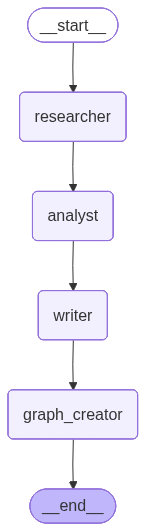

In [6]:
## ── Cell 6: Visualise the Graph Architecture ───────────────────────────────
from IPython.display import Image, display

try:
    img = research_graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception:
    # Fallback: print ASCII representation
    print(research_graph.get_graph().draw_ascii())

  MULTIAGENT RESEARCH SYSTEM — SMS
  Topic: population in india

🔍 [Researcher]  Researching: 'population in india' …
   → Research complete (3550 chars)

📊 [Analyst]  Extracting chartable data …
   → Extracted data: 7 data points

✍️  [Writer]  Drafting report …
   → Report ready (2958 chars)

🎨 [Graph Creator]  Building visualisation …


C:\Users\E264598\AppData\Local\Temp\ipykernel_22132\3719059453.py:160: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


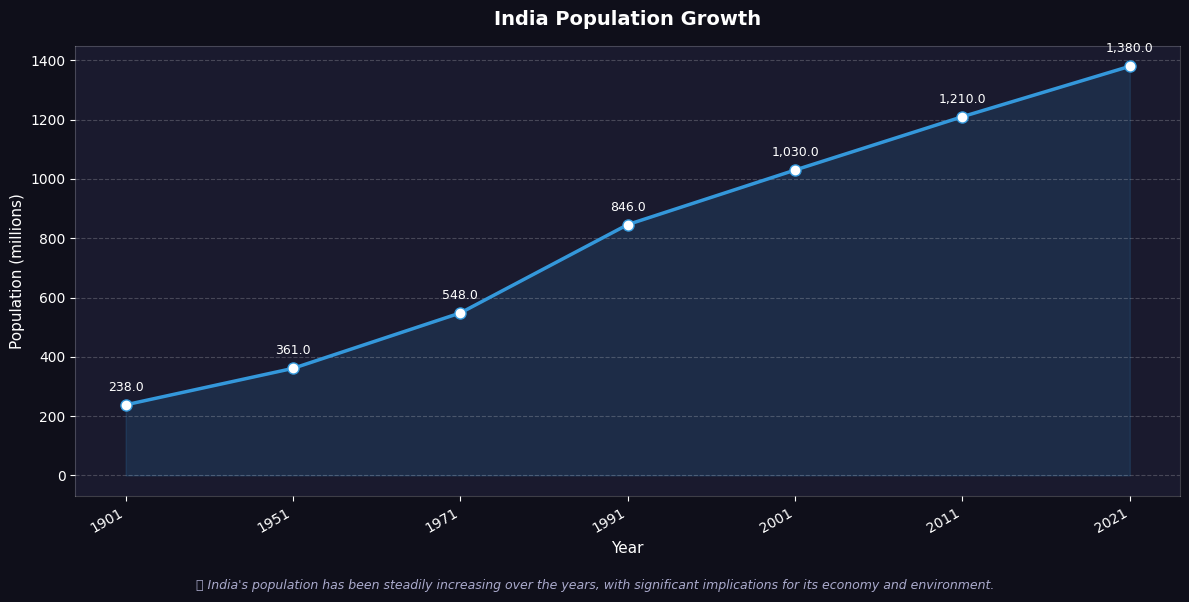

   → Chart saved: c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\Experiments\population_in_india_sms_chart.png

  ✅  All agents completed successfully!


In [8]:
## ── Cell 7: Run the Multiagent Research System ─────────────────────────────
from IPython.display import Markdown

# ┌──────────────────────────────────────────────────────────────┐
# │  👇  Change this topic to research anything you want         │
RESEARCH_TOPIC = "population in india"
# └──────────────────────────────────────────────────────────────┘

print("=" * 65)
print(f"  MULTIAGENT RESEARCH SYSTEM — prefix")
print(f"  Topic: {RESEARCH_TOPIC}")
print("=" * 65)

initial_state: ResearchState = {
    "topic":           RESEARCH_TOPIC,
    "research_notes":  "",
    "structured_data": {},
    "report":          "",
    "chart_path":      "",
}

final_state = research_graph.invoke(initial_state)

print("\n" + "=" * 65)
print("  ✅  All agents completed successfully!")
print("=" * 65)

In [9]:
## ── Cell 8: Display the Report ─────────────────────────────────────────────
from IPython.display import Markdown, display

print("\n" + "━" * 65)
print("  📄  RESEARCH REPORT")
print("━" * 65 + "\n")
display(Markdown(final_state["report"]))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📄  RESEARCH REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



### Executive Summary
India is the second-most populous country in the world, with a diverse population of approximately 1.38 billion people as of 2021. The country's population has been steadily increasing over the years, with significant implications for its economy, environment, and social structures. This report provides an overview of India's population, including its history, key statistics, and recent developments. The report highlights the challenges posed by population growth, including pressure on resources, infrastructure, and the environment, as well as the opportunities presented by a large and young workforce.

### Background
India's population has been growing steadily over the years, with significant milestones marked in 1901, 1951, 1971, 1991, 2001, 2011, and 2021. The population growth rate has been declining over the years, but the country still accounts for 18% of the world's population growth. The population is divided into urban and rural areas, with the urban population growing at a faster rate. As shown in the chart, India's population has been steadily increasing over the years, with significant implications for its economy and environment.

### Key Findings
The key findings of this report include:
* India's population is approximately 1.38 billion people, with an average annual growth rate of 1.2%.
* The urban population is 460 million, accounting for 34% of the total population, while the rural population is 920 million, accounting for 66% of the total population.
* The sex ratio is 943 females per 1,000 males, and the literacy rate is 77.7%.
* The life expectancy at birth is 69.5 years, and the infant mortality rate is 32 deaths per 1,000 live births.
* The total fertility rate is 2.3 children per woman.

### Data Highlights
The data highlights of this report include:
* The top five most populous states in India are Uttar Pradesh, Maharashtra, Bihar, West Bengal, and Madhya Pradesh.
* The top five most populous cities in India are Delhi, Mumbai, Kolkata, Bengaluru, and Chennai.
* India is expected to surpass China as the most populous country by 2027.
* The population of India is projected to reach 1.45 billion by 2025 and 1.66 billion by 2050.
* India has a significant population of youth, with 65% of the population under the age of 35.

### Conclusion
In conclusion, India's population growth poses significant challenges, including pressure on resources, infrastructure, and the environment. However, the country is also expected to benefit from a demographic dividend, with a large and young workforce contributing to the country's economic growth. The Indian government has implemented various population control measures, including the National Population Policy and the Mission Parivar Vikas. As the country continues to urbanize and grow, it is essential to address the challenges posed by population growth and to harness the opportunities presented by a large and young workforce.

In [10]:
## ── Cell 9: Display Chart Metadata & Raw Research Notes ────────────────────

# Chart data summary
data = final_state.get("structured_data", {})
if data:
    print("\n📊  Chart Data Extracted by Analyst Agent:")
    print(f"   Title      : {data.get('chart_title', 'N/A')}")
    print(f"   Chart type : {data.get('chart_type', 'N/A')}")
    print(f"   X-axis     : {data.get('x_label', 'N/A')}")
    print(f"   Y-axis     : {data.get('y_label', 'N/A')}")
    print(f"   Data points: {len(data.get('labels', []))}")
    print(f"   Insight    : {data.get('insight', 'N/A')}")
    if final_state.get("chart_path"):
        print(f"   Saved to   : {final_state['chart_path']}")
else:
    print("⚠️  No structured chart data was extracted.")

# Optionally show truncated raw notes
print("\n" + "─" * 65)
print("📝  Raw Research Notes (first 800 chars):")
print("─" * 65)
print(final_state["research_notes"][:800] + " …")


📊  Chart Data Extracted by Analyst Agent:
   Title      : India Population Growth
   Chart type : line
   X-axis     : Year
   Y-axis     : Population (millions)
   Data points: 7
   Insight    : India's population has been steadily increasing over the years, with significant implications for its economy and environment.
   Saved to   : c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\Experiments\population_in_india_sms_chart.png

─────────────────────────────────────────────────────────────────
📝  Raw Research Notes (first 800 chars):
─────────────────────────────────────────────────────────────────
**Overview**
India is the second-most populous country in the world, with a large and diverse population. The country's population has been steadily increasing over the years, with significant implications for its economy, environment, and social structures. As of 2021, India's population is approximately 1.38 billion people, accounting for

---
## 🔁 Run on a Different Topic

Change `RESEARCH_TOPIC` in **Cell 7** to any subject — for example:

```python
RESEARCH_TOPIC = "Artificial Intelligence in Healthcare"
RESEARCH_TOPIC = "Global Renewable Energy Transition"
RESEARCH_TOPIC = "Space Exploration milestones and budgets"
RESEARCH_TOPIC = "Cryptocurrency market history"
```

Then **re-run cells 7 → 8 → 9** to get a fresh report and chart.

---
### Architecture Recap

```
┌──────────┐     ┌─────────┐     ┌────────┐     ┌──────────────┐
│Researcher│────▶│ Analyst │────▶│ Writer │────▶│ Graph Creator│
└──────────┘     └─────────┘     └────────┘     └──────────────┘
  raw facts      JSON chart       markdown         matplotlib
  & stats           data           report            chart
```